In [1]:

import torch
print(torch.cuda.is_available())


from detecto import core, utils, visualize
from detecto.visualize import show_labeled_image, plot_prediction_grid
# from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
# import re
# import os

True


In [22]:
file_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/csv_files/All_data_csv/'

# load csv files
data_NZ2023_a_na = pd.read_csv(f'{file_path}data_NZ2023_a_na.csv')
data_NZ2023_b_na = pd.read_csv(f'{file_path}data_NZ2023_b_na.csv')
data_NZ2023_c_na = pd.read_csv(f'{file_path}data_NZ2023_c_na.csv')
data_NZ2023_d_na = pd.read_csv(f'{file_path}data_NZ2023_d_na.csv')
data_NZ2024_a_na = pd.read_csv(f'{file_path}data_NZ2024_a_na.csv')
data_NZ2024_b_na = pd.read_csv(f'{file_path}data_NZ2024_b_na.csv')
data_NZ2024_c_na = pd.read_csv(f'{file_path}data_NZ2024_c_na.csv')
data_NZ2024_d_na = pd.read_csv(f'{file_path}data_NZ2024_d_na.csv')
data_UK2024_a_na = pd.read_csv(f'{file_path}data_UK2024_a_na.csv')
data_UK2024_b_na = pd.read_csv(f'{file_path}data_UK2024_b_na.csv')
data_UK2024_c_na = pd.read_csv(f'{file_path}data_UK2024_c_na.csv')
data_UK2024_d_na = pd.read_csv(f'{file_path}data_UK2024_d_na.csv')

In [3]:
# Load model trained which we annotated to detect apples in rgb images using MAKESENSE.AI
model2 = core.Model.load("/media/data/model_weights.pth",['Apple'])

/home/ht21074/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ht21074/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [3]:
# Spectral folder

# Split by '/' and remove last split in string

data_NZ2023_a_na['Spectral_folder_a'] = data_NZ2023_a_na['Image_folder_A'].str.split('/').str[:-1].str.join('/')
data_NZ2023_b_na['Spectral_folder_b'] = data_NZ2023_b_na['Image_folder_B'].str.split('/').str[:-1].str.join('/')
data_NZ2023_c_na['Spectral_folder_c'] = data_NZ2023_c_na['Image_folder_C'].str.split('/').str[:-1].str.join('/')
data_NZ2023_d_na['Spectral_folder_d'] = data_NZ2023_d_na['Image_folder_D'].str.split('/').str[:-1].str.join('/')
data_NZ2024_a_na['Spectral_folder_a'] = data_NZ2024_a_na['Image_folder_A'].str.split('/').str[:-1].str.join('/')
data_NZ2024_b_na['Spectral_folder_b'] = data_NZ2024_b_na['Image_folder_B'].str.split('/').str[:-1].str.join('/')
data_NZ2024_c_na['Spectral_folder_c'] = data_NZ2024_c_na['Image_folder_C'].str.split('/').str[:-1].str.join('/')
data_NZ2024_d_na['Spectral_folder_d'] = data_NZ2024_d_na['Image_folder_D'].str.split('/').str[:-1].str.join('/')
data_UK2024_a_na['Spectral_folder_a'] = data_UK2024_a_na['Image_folder_A'].str.split('/').str[:-1].str.join('/')
data_UK2024_b_na['Spectral_folder_b'] = data_UK2024_b_na['Image_folder_B'].str.split('/').str[:-1].str.join('/')
data_UK2024_c_na['Spectral_folder_c'] = data_UK2024_c_na['Image_folder_C'].str.split('/').str[:-1].str.join('/')
data_UK2024_d_na['Spectral_folder_d'] = data_UK2024_d_na['Image_folder_D'].str.split('/').str[:-1].str.join('/')


In [4]:
test_data = data_NZ2023_a_na[:3]
print(test_data)

                                      Image_folder_A    image_filename_A  \
0  20230328 Fuji PFR orchard early pick/2023-03-2...  2023-03-28_002.png   
1  20230328 Fuji PFR orchard early pick/2023-03-2...  2023-03-28_002.png   
2  20230328 Fuji PFR orchard early pick/2023-03-2...  2023-03-28_002.png   

       ID  Number  Firmness1  Firmness2   Brix  Starch  Starch2    Streif  \
0  Fuji_1     1.0       6.38       6.23  12.43    50.0      8.0  4.057924   
1  Fuji_2     2.0       7.32       8.84  14.04    43.0      8.0  4.603989   
2  Fuji_3     3.0       8.02       8.86  11.53    80.0      4.0  2.928014   

   Avg_firmness Cultivar                                  Spectral_folder_a  
0         6.305     Fuji  20230328 Fuji PFR orchard early pick/2023-03-2...  
1         8.080     Fuji  20230328 Fuji PFR orchard early pick/2023-03-2...  
2         8.440     Fuji  20230328 Fuji PFR orchard early pick/2023-03-2...  


In [ ]:
# Using MAKESENSE.AI segregation
# This extracts the coordinates of the bounding boxes for each apple for each image

c = 0
thresh = 0.8

# image_name is the image_file_name in the csv file
# loc_link is the folder location of the image 

def extractor(image_name, model, loc_link):
    global c

    c += 1
    print(c)
    folder_link = "/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/"
    folder_link = folder_link
        
    # image_link = folder_link + image_name
    

    image_link = folder_link + loc_link + '/' 
    image_link_path = image_link + image_name

    # print(image_link_path)
    
    # image = utils.read_image(image_link)


    # image_path = os.path(image_link_path)
    image = utils.read_image(image_link_path)

    predictions = model.predict(image)
    labels, boxes, scores = predictions
    # show_labeled_image(image, boxes, labels)

    filtered_indices = np.where(scores > thresh)
    filtered_scores = scores[filtered_indices]
    filtered_boxes = boxes[filtered_indices]
    num_list = filtered_indices[0].tolist()
    filtered_labels = [labels[i] for i in num_list]
    # show_labeled_image(image, filtered_boxes, filtered_labels)

    # tenosrs are sorted on their y position  - e.g they are sorted from top to bottom
    sorted_tensor = filtered_boxes[np.lexsort((filtered_boxes[:, 1],))]

    # for when there are odd number of apples (boxes) and more than 3 apples
    if len(filtered_boxes) > 3 and len(filtered_boxes) % 2 == 0:

        # Determine the number of rows in the sorted tensor
        num_rows = int(len(sorted_tensor) / 2)

        # Sort each row from left to right (based on xmin)
        sorted_tensor = torch.tensor(
            np.concatenate(
                [
                    sorted_tensor[i : i + num_rows, :][
                        np.lexsort((sorted_tensor[i : i + num_rows, 0],))
                    ]
                    for i in range(0, len(sorted_tensor), num_rows)
                ]
            )
        )
    # for when there are even number of apples (boxes) and more than 3 apples
    elif len(filtered_boxes) > 3 and len(filtered_boxes) % 2 != 0:

        # Determine the number of rows in the sorted tensor
        num_rows = int(len(sorted_tensor) / 2) + 1

        # Sort each row from left to right (based on xmin)
        sorted_tensor = torch.tensor(
            np.concatenate(
                [
                    sorted_tensor[i : i + num_rows, :][np.lexsort((sorted_tensor[i : i + num_rows, 0],))]
                    for i in range(0, len(sorted_tensor), num_rows)
                ]
            )
        )

    # for when there are less than 4 apples
    elif len(filtered_boxes) < 4:

        coordinates = [(box[0], box[1], box[2], box[3]) for box in filtered_boxes]

        # Step 2: Calculate center points
        center_points = [
            (0.5 * (x1 + x2), 0.5 * (y1 + y2)) for (x1, y1, x2, y2) in coordinates
        ]

        # Step 3: Sort bounding boxes based on x-coordinate of center point
        sorted_indices = sorted(
            range(len(center_points)), key=lambda k: center_points[k][0]
        )
        sorted_coordinates = [coordinates[i] for i in sorted_indices]

        # Step 4: Update the original tensor list
        sorted_tensor = [torch.tensor(coord) for coord in sorted_coordinates]

    return sorted_tensor

In [5]:
NZ2023_loc_link = 'spectral_NZ_2023'
NZ2024_loc_link = 'spectral_NZ_2024'
UK2024_loc_link = 'spectral_UK_2024'

test_data['sorted_tensor'] = test_data['Image_folder_A'].apply(lambda x: extractor(x, model2, NZ2023_loc_link))


NameError: name 'extractor' is not defined

In [ ]:
NZ2023_loc_link = 'spectral_NZ_2023'
NZ2024_loc_link = 'spectral_NZ_2024'
UK2024_loc_link = 'spectral_UK_2024'

data_NZ2023_a_na['sorted_tensor'] = data_NZ2023_a_na['Image_folder_A'].apply(lambda x: extractor(x, model2, NZ2023_loc_link))
data_NZ2023_b_na['sorted_tensor'] = data_NZ2023_b_na['Image_folder_B'].apply(lambda x: extractor(x, model2, NZ2023_loc_link))
data_NZ2023_c_na['sorted_tensor'] = data_NZ2023_c_na['Image_folder_C'].apply(lambda x: extractor(x, model2, NZ2023_loc_link)) 
data_NZ2023_d_na['sorted_tensor'] = data_NZ2023_d_na['Image_folder_D'].apply(lambda x: extractor(x, model2, NZ2023_loc_link))
data_NZ2023_a_na['sorted_tensor'].head(5)

data_NZ2024_a_na['sorted_tensor'] = data_NZ2024_a_na['Image_folder_A'].apply(lambda x: extractor(x, model2, NZ2024_loc_link))
data_NZ2024_b_na['sorted_tensor'] = data_NZ2024_b_na['Image_folder_B'].apply(lambda x: extractor(x, model2, NZ2024_loc_link))
data_NZ2024_c_na['sorted_tensor'] = data_NZ2024_c_na['Image_folder_C'].apply(lambda x: extractor(x, model2, NZ2024_loc_link)) 
data_NZ2024_d_na['sorted_tensor'] = data_NZ2024_d_na['Image_folder_D'].apply(lambda x: extractor(x, model2, NZ2024_loc_link))
data_NZ2024_a_na['sorted_tensor'].head(5)



data_UK2024_a_na['sorted_tensor'] = data_UK2024_a_na['Image_folder_A'].apply(lambda x: extractor(x, model2, UK2024_loc_link))
data_UK2024_b_na['sorted_tensor'] = data_UK2024_b_na['Image_folder_B'].apply(lambda x: extractor(x, model2, UK2024_loc_link))
data_UK2024_c_na['sorted_tensor'] = data_UK2024_c_na['Image_folder_C'].apply(lambda x: extractor(x, model2, UK2024_loc_link)) 
data_UK2024_d_na['sorted_tensor'] = data_UK2024_d_na['Image_folder_D'].apply(lambda x: extractor(x, model2, UK2024_loc_link))
data_UK2024_a_na['sorted_tensor'].head(5)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


0    [[tensor(29.8971), tensor(121.5800), tensor(16...
1    [[tensor(29.8971), tensor(121.5800), tensor(16...
2    [[tensor(29.8971), tensor(121.5800), tensor(16...
3    [[tensor(29.8971), tensor(121.5800), tensor(16...
4    [[tensor(29.8971), tensor(121.5800), tensor(16...
Name: sorted_tensor, dtype: object

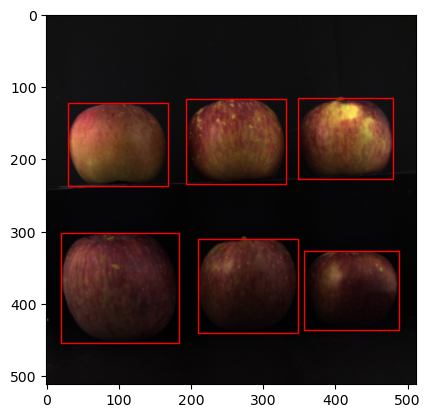

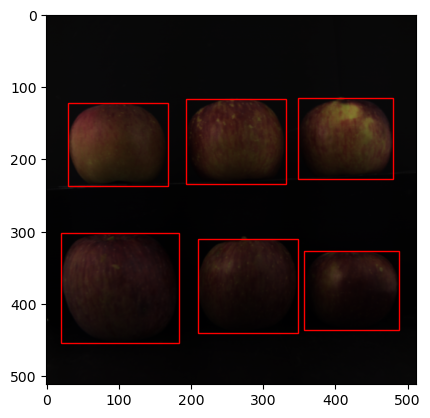

In [ ]:
# rgb_image = utils.read_image('/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/spectral_NZ_2023/20230328 Fuji PFR orchard early pick/2023-03-28_002/2023-03-28_002.png')
# show_labeled_image(rgb_image, data_NZ2023_a_na['sorted_tensor'].iloc[0])
# # print(test_data['test_tensor'].iloc[0])

# dat_files = "/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/spectral_NZ_2023/20230328 Fuji PFR orchard early pick/2023-03-28_002/results/REFLECTANCE_2023-03-28_002.dat"

# height, width, bands = 512, 512, 204
# spectral_data = np.fromfile(dat_files, dtype=np.float32)
# bands = len(spectral_data) // (height * width)
# spectral_data = spectral_data.reshape(height, bands, width)
# spectral_data = np.transpose(spectral_data, (2, 0, 1))  # Convert to (H, W, B)
# # reconstruct RGB image from hyperspectral data
# spectral_data = spectral_data.astype(np.float32) / 65535.0
# spectral_data = (spectral_data - spectral_data.min()) / (spectral_data.max() - spectral_data.min())
# # print(f'Max value: {np.max(spectral_data)}, Min value: {np.min(spectral_data)}')
# red_band = spectral_data[:, :, 70] # the channel that is red
# green_band = spectral_data[:, :, 53] # the channel that is green
# blue_band = spectral_data[:, :, 19] # the channel that is blue
# reconstructed_rgb_img = np.stack([red_band, green_band, blue_band], axis=-1)

# reconstructed_rgb_img_flipped = np.fliplr(reconstructed_rgb_img)

# show_labeled_image(reconstructed_rgb_img_flipped, data_NZ2023_a_na['sorted_tensor'].iloc[0])

#         # Display image
#         # plt.imshow(rgb_image)
#         # plt.axis("off")
#         # plt.title("RGB Composite from Hyperspectral Data extracted from tensor")
#         # plt.show()

#         # Find tensors and sort from reconstructed RGB image



In [ ]:
# Get a small dataset
# data_test = data_NZ2023_a_na[0:10]


In [ ]:
# NZ2023_loc_link = 'spectral_NZ_2023'
# data_test['sorted_tensor'] = data_test['Image_folder_A'].apply(lambda x: extractor(x, model2, NZ2023_loc_link))


In [ ]:
# pd.options.display.max_colwidth = None
# print(data_test['sorted_tensor'][])

In [ ]:
# print(data_test)

In [15]:
def lengther(data):
    return len(data)

In [16]:
# Get count of apples detected from each png file

# data_test['number_of_apples'] = data_test['sorted_tensor'].apply(lambda x: lengther(x))

data_NZ2023_a_na['number_of_apples'] = data_NZ2023_a_na['sorted_tensor'].apply(lambda x: lengther(x))
data_NZ2023_b_na['number_of_apples'] = data_NZ2023_b_na['sorted_tensor'].apply(lambda x: lengther(x))
data_NZ2023_c_na['number_of_apples'] = data_NZ2023_c_na['sorted_tensor'].apply(lambda x: lengther(x))
data_NZ2023_d_na['number_of_apples'] = data_NZ2023_d_na['sorted_tensor'].apply(lambda x: lengther(x))
print(data_NZ2023_a_na.head(n=5))

data_NZ2024_a_na['number_of_apples'] = data_NZ2024_a_na['sorted_tensor'].apply(lambda x: lengther(x))
data_NZ2024_b_na['number_of_apples'] = data_NZ2024_b_na['sorted_tensor'].apply(lambda x: lengther(x))
data_NZ2024_c_na['number_of_apples'] = data_NZ2024_c_na['sorted_tensor'].apply(lambda x: lengther(x))
data_NZ2024_d_na['number_of_apples'] = data_NZ2024_d_na['sorted_tensor'].apply(lambda x: lengther(x))
print(data_NZ2024_a_na.head(n=5))

data_UK2024_a_na['number_of_apples'] = data_UK2024_a_na['sorted_tensor'].apply(lambda x: lengther(x))
data_UK2024_b_na['number_of_apples'] = data_UK2024_b_na['sorted_tensor'].apply(lambda x: lengther(x))
data_UK2024_c_na['number_of_apples'] = data_UK2024_c_na['sorted_tensor'].apply(lambda x: lengther(x))
data_UK2024_d_na['number_of_apples'] = data_UK2024_d_na['sorted_tensor'].apply(lambda x: lengther(x))
print(data_UK2024_a_na.head(n=5))

                                      Image_folder_A    image_filename_A  \
0  20230328 Fuji PFR orchard early pick/2023-03-2...  2023-03-28_002.png   
1  20230328 Fuji PFR orchard early pick/2023-03-2...  2023-03-28_002.png   
2  20230328 Fuji PFR orchard early pick/2023-03-2...  2023-03-28_002.png   
3  20230328 Fuji PFR orchard early pick/2023-03-2...  2023-03-28_002.png   
4  20230328 Fuji PFR orchard early pick/2023-03-2...  2023-03-28_002.png   

       ID  Number  Firmness1  Firmness2   Brix  Starch  Starch2    Streif  \
0  Fuji_1     1.0       6.38       6.23  12.43    50.0      8.0  4.057924   
1  Fuji_2     2.0       7.32       8.84  14.04    43.0      8.0  4.603989   
2  Fuji_3     3.0       8.02       8.86  11.53    80.0      4.0  2.928014   
3  Fuji_4     4.0       6.36       7.82  12.18    63.0      7.0  4.074713   
4  Fuji_5     5.0       8.13       7.38  12.10    45.0      8.0  5.127273   

   Avg_firmness Cultivar                                      sorted_tensor  \
0

In [17]:
# Check each harvest_data for number of apples expected in an image and checking there is the same number in the image folder
# 'number_of_apples' is the number of apples from the same image folder 
# 'Count' is the number of apples found using the map function within the image

# name_counts_test = data_test['Image_folder_A'].value_counts()
# # Create a new column with the counts
# data_test['Count'] = data_test['Image_folder_A'].map(name_counts_test)
# indices_test_a = np.where(data_test['Count'].values != data_test['number_of_apples'].values)[0]
# # Print the indices
# print(indices_test_a)
# print(len(indices_test_a))
# missing_img_NZ2023_a = [] 
# for i in indices_test_a:
#     missing_img_NZ2023_a.append(data_test['Image_folder_A'].iloc[i])


name_counts_NZ2023 = data_NZ2023_a_na['Image_folder_A'].value_counts()
# Create a new column with the counts
data_NZ2023_a_na['Count'] = data_NZ2023_a_na['Image_folder_A'].map(name_counts_NZ2023)
indices_NZ2023_a = np.where(data_NZ2023_a_na['Count'].values != data_NZ2023_a_na['number_of_apples'].values)[0]
# Print the indices
print(indices_NZ2023_a)
print(len(indices_NZ2023_a))
missing_img_NZ2023_a = [] 
for i in indices_NZ2023_a:
    missing_img_NZ2023_a.append(data_NZ2023_a_na['Image_folder_A'].iloc[i])




name_counts_NZ2024 = data_NZ2024_a_na['Image_folder_A'].value_counts()
# Create a new column with the counts
data_NZ2024_a_na['Count'] = data_NZ2024_a_na['Image_folder_A'].map(name_counts_NZ2024)
indices_NZ2024_a = np.where(data_NZ2024_a_na['Count'].values != data_NZ2024_a_na['number_of_apples'].values)[0]
# Print the indices
print(indices_NZ2024_a)
print(len(indices_NZ2024_a))
missing_img_NZ2024_a = [] 
for i in indices_NZ2024_a:
    missing_img_NZ2024_a.append(data_NZ2024_a_na['Image_folder_A'].iloc[i])




name_counts_UK2024= data_UK2024_a_na['Image_folder_A'].value_counts()
# Create a new column with the counts
data_UK2024_a_na['Count'] = data_UK2024_a_na['Image_folder_A'].map(name_counts_UK2024)
indices_UK2024_a = np.where(data_UK2024_a_na['Count'].values != data_UK2024_a_na['number_of_apples'].values)[0]
# Print the indices
print(indices_UK2024_a)
print(len(indices_UK2024_a))
missing_img_UK2024_a = [] 
for i in indices_UK2024_a:
    missing_img_UK2024_a.append(data_UK2024_a_na['Image_folder_A'].iloc[i])

[ 929  930  931  932  933  934  935 1142]
8
[296 297 298 299 300 301 302 303 304 305 334 335 336 337 338 339 633 634
 635 636 637 638 663 664 665 666 667 668 771 772 773 774 775 776 777 778
 779 780 781 782 783 784 785 786 787 788 815 816 817 818 819 820 821 822
 823 824 825 826 827 828 829 830 831 832 940 941 942 943 944]
69
[  10   11   12   13   14   15   22   23   24   25   26   27   28   29
   30   31   32   33   34   35   36   37   38   39   40   41   42   43
   44   45   97   98   99  100  101  102  103  118  119  120  121  122
  123  124  125  126  127  128  129  130  131  139  140  141  142  143
  144  145  146  147  148  149  150  151  152  160  161  162  163  164
  165  166  167  168  169  170  171  172  173  202  203  204  205  206
  207  208  447  448  449  450  451  452  453  454  455  456  457  458
  459  460  601  602  603  604  605  606  607  689  690  691  692  978
  979  980  981  982  983  984  985  993  994  995  996  997  998 1752
 1753 1754 1755 1756 1757 1758 17

In [18]:
name_counts_NZ2023 = data_NZ2023_b_na['Image_folder_B'].value_counts()
# Create a new column with the counts
data_NZ2023_b_na['Count'] = data_NZ2023_b_na['Image_folder_B'].map(name_counts_NZ2023)
indices_NZ2023_b = np.where(data_NZ2023_b_na['Count'].values != data_NZ2023_b_na['number_of_apples'].values)[0]
# Print the indices
print(indices_NZ2023_b)
print(len(indices_NZ2023_b))
missing_img_NZ2023_b = [] 
for i in indices_NZ2023_b:
    missing_img_NZ2023_b.append(data_NZ2023_b_na['Image_folder_B'].iloc[i])




name_counts_NZ2024 = data_NZ2024_b_na['Image_folder_B'].value_counts()
# Create a new column with the counts
data_NZ2024_b_na['Count'] = data_NZ2024_b_na['Image_folder_B'].map(name_counts_NZ2024)
indices_NZ2024_b = np.where(data_NZ2024_b_na['Count'].values != data_NZ2024_b_na['number_of_apples'].values)[0]
# Print the indices
print(indices_NZ2024_b)
print(len(indices_NZ2024_b))
missing_img_NZ2024_b = [] 
for i in indices_NZ2024_b:
    missing_img_NZ2024_b.append(data_NZ2024_b_na['Image_folder_B'].iloc[i])




name_counts_UK2024= data_UK2024_b_na['Image_folder_B'].value_counts()
# Create a new column with the counts
data_UK2024_b_na['Count'] = data_UK2024_b_na['Image_folder_B'].map(name_counts_UK2024)
indices_UK2024_b = np.where(data_UK2024_b_na['Count'].values != data_UK2024_b_na['number_of_apples'].values)[0]
# Print the indices
print(indices_UK2024_b)
print(len(indices_UK2024_b))
missing_img_UK2024_b = [] 
for i in indices_UK2024_b:
    missing_img_UK2024_b.append(data_UK2024_b_na['Image_folder_B'].iloc[i])

[ 929  930  931  932  933  934  935 1142]
8
[ 296  297  298  299  300  301  302  303  304  305  633  634  635  636
  637  638  645  646  647  648  649  650  657  658  659  660  661  662
  663  664  665  666  667  668  759  760  761  762  763  764  777  778
  779  780  781  782  783  784  785  786  787  788  789  790  791  792
  793  794  795  796  797  798  799  800  815  816  817  818  819  820
  821  822  823  824  825  826  827  828  829  830  831  832  857  858
  859  860  861  862  940  941  942  943  944 1285 1286 1287 1288]
97
[   4    5    6    7    8    9   10   11   12   13   14   15   16   17
   18   19   20   21   22   23   24   25   26   27   28   29   30   31
   32   33   34   35   36   37   38   39   40   41   42   43   44   45
   69   70   71   72   73   74   75   97   98   99  100  101  102  103
  125  126  127  128  129  130  131  139  140  141  142  143  144  145
  146  147  148  149  150  151  152  160  161  162  163  164  165  166
  258  259  260  261  262  263  26

In [19]:
name_counts_NZ2023 = data_NZ2023_c_na['Image_folder_C'].value_counts()
# Create a new column with the counts
data_NZ2023_c_na['Count'] = data_NZ2023_c_na['Image_folder_C'].map(name_counts_NZ2023)
indices_NZ2023_c = np.where(data_NZ2023_c_na['Count'].values != data_NZ2023_c_na['number_of_apples'].values)[0]
# Print the indices
print(indices_NZ2023_c)
print(len(indices_NZ2023_c))
missing_img_NZ2023_c = [] 
for i in indices_NZ2023_c:
    missing_img_NZ2023_c.append(data_NZ2023_c_na['Image_folder_C'].iloc[i])




name_counts_NZ2024 = data_NZ2024_c_na['Image_folder_C'].value_counts()
# Create a new column with the counts
data_NZ2024_c_na['Count'] = data_NZ2024_c_na['Image_folder_C'].map(name_counts_NZ2024)
indices_NZ2024_c = np.where(data_NZ2024_c_na['Count'].values != data_NZ2024_c_na['number_of_apples'].values)[0]
# Print the indices
print(indices_NZ2024_c)
print(len(indices_NZ2024_c))
missing_img_NZ2024_c = [] 
for i in indices_NZ2024_c:
    missing_img_NZ2024_c.append(data_NZ2024_c_na['Image_folder_C'].iloc[i])




name_counts_UK2024= data_UK2024_c_na['Image_folder_C'].value_counts()
# Create a new column with the counts
data_UK2024_c_na['Count'] = data_UK2024_c_na['Image_folder_C'].map(name_counts_UK2024)
indices_UK2024_c = np.where(data_UK2024_c_na['Count'].values != data_UK2024_c_na['number_of_apples'].values)[0]
# Print the indices
print(indices_UK2024_c)
print(len(indices_UK2024_c))
missing_img_UK2024_c = [] 
for i in indices_UK2024_c:
    missing_img_UK2024_c.append(data_UK2024_c_na['Image_folder_C'].iloc[i])

[ 929  930  931  932  933  934  935 1142]
8
[209 210 211 212 213 214 215 296 297 298 299 300 301 302 303 304 305 633
 634 635 636 637 638 657 658 659 660 661 662 759 760 761 762 763 764 771
 772 773 774 775 776 777 778 779 780 781 782 783 784 785 786 787 788 789
 790 791 792 793 794 821 822 823 824 825 826 839 840 841 842 843 844 857
 858 859 860 861 862 869 870 871 872 873 874 940 941 942 943 944]
88
[   4    5    6    7    8    9   10   11   12   13   14   15   16   17
   18   19   20   21   22   23   24   25   26   27   34   35   36   37
   38   39   40   41   42   43   44   45   46   47   48   49   50   51
  104  105  106  107  108  109  110  125  126  127  128  129  130  131
  139  140  141  142  143  144  145  146  147  148  149  150  151  152
  160  161  162  163  164  165  166  307  308  309  310  311  312  313
  314  315  316  317  318  319  320  693  694  695  696  697  698  699
  838  839  840  841  842  843  844  978  979  980  981  982  983  984
  985  986  987  988  989  

In [20]:
name_counts_NZ2023 = data_NZ2023_d_na['Image_folder_D'].value_counts()
# Create a new column with the counts
data_NZ2023_d_na['Count'] = data_NZ2023_d_na['Image_folder_D'].map(name_counts_NZ2023)
indices_NZ2023_d = np.where(data_NZ2023_d_na['Count'].values != data_NZ2023_d_na['number_of_apples'].values)[0]
# Print the indices
print(indices_NZ2023_d)
print(len(indices_NZ2023_d))
missing_img_NZ2023_d = [] 
for i in indices_NZ2023_d:
    missing_img_NZ2023_d.append(data_NZ2023_d_na['Image_folder_D'].iloc[i])




name_counts_NZ2024 = data_NZ2024_d_na['Image_folder_D'].value_counts()
# Create a new column with the counts
data_NZ2024_d_na['Count'] = data_NZ2024_d_na['Image_folder_D'].map(name_counts_NZ2024)
indices_NZ2024_d = np.where(data_NZ2024_d_na['Count'].values != data_NZ2024_d_na['number_of_apples'].values)[0]
# Print the indices
print(indices_NZ2024_d)
print(len(indices_NZ2024_d))
missing_img_NZ2024_d = [] 
for i in indices_NZ2024_d:
    missing_img_NZ2024_d.append(data_NZ2024_d_na['Image_folder_D'].iloc[i])




name_counts_UK2024= data_UK2024_d_na['Image_folder_D'].value_counts()
# Create a new column with the counts
data_UK2024_d_na['Count'] = data_UK2024_d_na['Image_folder_D'].map(name_counts_UK2024)
indices_UK2024_d = np.where(data_UK2024_d_na['Count'].values != data_UK2024_d_na['number_of_apples'].values)[0]
# Print the indices
print(indices_UK2024_d)
print(len(indices_UK2024_d))
missing_img_UK2024_d = [] 
for i in indices_UK2024_d:
    missing_img_UK2024_d.append(data_UK2024_d_na['Image_folder_D'].iloc[i])

[1142]
1
[ 296  297  298  299  300  301  302  303  304  305  621  622  623  624
  625  626  645  646  647  648  649  650  657  658  659  660  661  662
  669  670  671  672  673  674  759  760  761  762  763  764  765  766
  767  768  769  770  771  772  773  774  775  776  777  778  779  780
  781  782  783  784  785  786  787  788  789  790  791  792  793  794
  821  822  823  824  825  826  851  852  853  854  855  856  857  858
  859  860  861  862  869  870  871  872  873  874  875  876  877  878
  879  880  893  894  895  896  897  898  940  941  942  943  944  957
  958  959  960  961  962 1115 1116 1117 1118 1119 1120 1121 1122 1123
 1124 1125 1126]
129
[   0    1    2    3   10   11   12   13   14   15   22   23   24   25
   26   27   28   29   30   31   32   33   34   35   36   37   38   39
   40   41   42   43   44   45   46   47   48   49   50   51   97   98
   99  100  101  102  103  104  105  106  107  108  109  110  111  112
  113  114  115  116  117  118  119  120  121  

In [21]:
# # print(missing_img_nz_a)
# missing_img_unique_NZ2023_a = list(set(missing_img_NZ2023_a))
# print(missing_img_unique_NZ2023_a)
# print(len(missing_img_unique_NZ2023_a))


# print(missing_img_nz2023_a)
missing_img_unique_nz2023_a = list(set(missing_img_NZ2023_a))
print(missing_img_unique_nz2023_a)
print(len(missing_img_unique_nz2023_a))


# print(missing_img_nz2024_a)
missing_img_unique_nz2024_a = list(set(missing_img_NZ2024_a))
print(missing_img_unique_nz2024_a)
print(len(missing_img_unique_nz2024_a))


# print(missing_img_UK2024_a)
missing_img_unique_uk2024_a = list(set(missing_img_UK2024_a))
print(missing_img_unique_uk2024_a)
print(len(missing_img_UK2024_a))

['20230303 Cox 80 fruit 4 side ea/2023-03-03_021/2023-03-03_021.png', '20230308 Golden Delicious 133 fruit/2023-03-08_028 (1)/2023-03-08_028 (1).png']
2
['20240309 Gala FOPs/2024-03-09_041/2024-03-09_041.png', '20240328 Fuji/2024-03-28_013/2024-03-28_013.png', '20240309 Fuji/2024-03-09_017/2024-03-09_017.png', '20240328 Fuji/2024-03-28_005/2024-03-28_005.png', '20240327 Braeburn Nelson/2024-03-27_030/2024-03-27_030.png', '20240318 Gala FOPs/2024-03-18_054/2024-03-18_054.png', '20240327 Braeburn Nelson/2024-03-27_034/2024-03-27_034.png', '20240309 Fuji/2024-03-09_013/2024-03-09_013.png', '20240318 Gala FOPs/2024-03-18_074/2024-03-18_074.png', '20240328 Fuji/2024-03-28_009/2024-03-28_009.png', '20240404 Fuji Breeding team/2024-04-04_027/2024-04-04_027.png', '20240327 Braeburn Nelson/2024-03-27_038/2024-03-27_038.png']
12
['20240911Cox-Gala-Fuji/038/038.png', '20240913Cox-Gala/135/135.png', '20241014GDgalaBB/1090/1090.png', '20240913Cox-Gala/087/087.png', '20240920GalaBraeburnGala/418/418

In [22]:

# print(missing_img_nz2023_b)
missing_img_unique_nz2023_b = list(set(missing_img_NZ2023_b))
print(missing_img_unique_nz2023_b)
print(len(missing_img_unique_nz2023_b))


# print(missing_img_nz2024_b)
missing_img_unique_nz2024_b = list(set(missing_img_NZ2024_b))
print(missing_img_unique_nz2024_b)
print(len(missing_img_unique_nz2024_b))


# print(missing_img_UK2024_b)
missing_img_unique_uk2024_b = list(set(missing_img_UK2024_b))
print(missing_img_unique_uk2024_b)
print(len(missing_img_UK2024_b))

['20230303 Cox 80 fruit 4 side ea/2023-03-03_022/2023-03-03_022.png', '20230308 Golden Delicious 133 fruit/2023-03-08_029 (1)/2023-03-08_029 (1).png']
2
['20240318 Gala FOPs/2024-03-18_071/2024-03-18_071.png', '20240327 Braeburn Nelson/2024-03-27_043/2024-03-27_043.png', '20240327 Braeburn Nelson/2024-03-27_023/2024-03-27_023.png', '20240408 Fuji Evendyn PFRX/2024-04-08_074/2024-04-08_074.png', '20240404 Fuji Breeding team/2024-04-04_028/2024-04-04_028.png', '20240328 Fuji/2024-03-28_010/2024-03-28_010.png', '20240309 Fuji/2024-03-09_014/2024-03-09_014.png', '20240328 Fuji/2024-03-28_006/2024-03-28_006.png', '20240328 Fuji/2024-03-28_014/2024-03-28_014.png', '20240318 Gala FOPs/2024-03-18_075/2024-03-18_075.png', '20240328 Fuji/2024-03-28_034/2024-03-28_034.png', '20240327 Braeburn Nelson/2024-03-27_039/2024-03-27_039.png', '20240327 Braeburn Nelson/2024-03-27_035/2024-03-27_035.png', '20240318 Gala FOPs/2024-03-18_055/2024-03-18_055.png', '20240309 Fuji/2024-03-09_018/2024-03-09_018.p

In [23]:

# print(missing_img_nz2023_c)
missing_img_unique_nz2023_c = list(set(missing_img_NZ2023_c))
print(missing_img_unique_nz2023_c)
print(len(missing_img_unique_nz2023_c))


# print(missing_img_nz2024_c)
missing_img_unique_nz2024_c = list(set(missing_img_NZ2024_c))
print(missing_img_unique_nz2024_c)
print(len(missing_img_unique_nz2024_c))


# print(missing_img_UK2024_c)
missing_img_unique_uk2024_c = list(set(missing_img_UK2024_c))
print(missing_img_unique_uk2024_c)
print(len(missing_img_UK2024_c))

['20230308 Golden Delicious 133 fruit/2023-03-08_030 (1)/2023-03-08_030 (1).png', '20230303 Cox 80 fruit 4 side ea/2023-03-03_023/2023-03-03_023.png']
2
['20240327 Braeburn Nelson/2024-03-27_040/2024-03-27_040.png', '20240318 Gala FOPs/2024-03-18_056/2024-03-18_056.png', '20240309 Fuji/2024-03-09_019/2024-03-09_019.png', '20240318 Gala FOPs/2024-03-18_072/2024-03-18_072.png', '20240309 Fuji/2024-03-09_015/2024-03-09_015.png', '20240327 Braeburn Nelson/2024-03-27_024/2024-03-27_024.png', '20240327 Braeburn Nelson/2024-03-27_044/2024-03-27_044.png', '20240328 Fuji/2024-03-28_035/2024-03-28_035.png', '20240327 Braeburn Nelson/2024-03-27_032/2024-03-27_032.png', '20240327 Braeburn Nelson/2024-03-27_036/2024-03-27_036.png', '20240308 Gala FOPs/2024-03-08_048/2024-03-08_048.png', '20240328 Fuji/2024-03-28_011/2024-03-28_011.png', '20240404 Fuji Breeding team/2024-04-04_029/2024-04-04_029.png', '20240328 Fuji/2024-03-28_043/2024-03-28_043.png', '20240328 Fuji/2024-03-28_023/2024-03-28_023.png

In [24]:

# print(missing_img_nz2023_d)
missing_img_unique_nz2023_d = list(set(missing_img_NZ2023_d))
print(missing_img_unique_nz2023_d)
print(len(missing_img_unique_nz2023_d))


# print(missing_img_nz2024_d)
missing_img_unique_nz2024_d = list(set(missing_img_NZ2024_d))
print(missing_img_unique_nz2024_d)
print(len(missing_img_unique_nz2024_d))


# print(missing_img_UK2024_d)
missing_img_unique_uk2024_d = list(set(missing_img_UK2024_d))
print(missing_img_unique_uk2024_d)
print(len(missing_img_unique_uk2024_d))

['20230303 Cox 80 fruit 4 side ea/2023-03-03_024/2023-03-03_024.png']
1
['20240327 Braeburn Nelson/2024-03-27_041/2024-03-27_041.png', '20240404-05 Fuji Nelson and PFRX/2024-04-05_092/2024-04-05_092.png', '20240327 Braeburn Nelson/2024-03-27_037/2024-03-27_037.png', '20240327 Braeburn Nelson/2024-03-27_045/2024-03-27_045.png', '20240404 Fuji Breeding team/2024-04-04_045/2024-04-04_045.png', '20240327 Braeburn Nelson/2024-03-27_033/2024-03-27_033.png', '20240327 Braeburn Nelson/2024-03-27_025/2024-03-27_025.png', '20240309 Fuji/2024-03-09_020/2024-03-09_020.png', '20240318 Gala FOPs/2024-03-18_073/2024-03-18_073.png', '20240328 Fuji/2024-03-28_044/2024-03-28_044.png', '20240328 Fuji/2024-03-28_032/2024-03-28_032.png', '20240404-05 Fuji Nelson and PFRX/2024-04-05_088/2024-04-05_088.png', '20240328 Fuji/2024-03-28_036/2024-03-28_036.png', '20240404 Fuji Breeding team/2024-04-04_030/2024-04-04_030.png', '20240328 Fuji/2024-03-28_048/2024-03-28_048.png', '20240327 Braeburn Nelson/2024-03-27

In [25]:
# # removing rows which miscount the number of apples in the image

# data_NZ2023_a_final_test = data_test[~data_test.index.isin(indices_test_a)]

data_NZ2023_a_final = data_NZ2023_a_na[~data_NZ2023_a_na.index.isin(indices_NZ2023_a)]
data_NZ2023_b_final = data_NZ2023_b_na[~data_NZ2023_b_na.index.isin(indices_NZ2023_b)]
data_NZ2023_c_final = data_NZ2023_c_na[~data_NZ2023_c_na.index.isin(indices_NZ2023_c)]
data_NZ2023_d_final = data_NZ2023_d_na[~data_NZ2023_d_na.index.isin(indices_NZ2023_d)]
# Reset the index
data_NZ2023_a_final = data_NZ2023_a_final.reset_index(drop=True)
data_NZ2023_b_final = data_NZ2023_b_final.reset_index(drop=True)
data_NZ2023_c_final = data_NZ2023_c_final.reset_index(drop=True)
data_NZ2023_d_final = data_NZ2023_d_final.reset_index(drop=True)



data_NZ2024_a_final = data_NZ2024_a_na[~data_NZ2024_a_na.index.isin(indices_NZ2024_a)]
data_NZ2024_b_final = data_NZ2024_b_na[~data_NZ2024_b_na.index.isin(indices_NZ2024_b)]
data_NZ2024_c_final = data_NZ2024_c_na[~data_NZ2024_c_na.index.isin(indices_NZ2024_c)]
data_NZ2024_d_final = data_NZ2024_d_na[~data_NZ2024_d_na.index.isin(indices_NZ2024_d)]
# Reset the index
data_NZ2024_a_final = data_NZ2024_a_final.reset_index(drop=True)
data_NZ2024_b_final = data_NZ2024_b_final.reset_index(drop=True)
data_NZ2024_c_final = data_NZ2024_c_final.reset_index(drop=True)
data_NZ2024_d_final = data_NZ2024_d_final.reset_index(drop=True)


data_UK2024_a_final = data_UK2024_a_na[~data_UK2024_a_na.index.isin(indices_UK2024_a)]
data_UK2024_b_final = data_UK2024_b_na[~data_UK2024_b_na.index.isin(indices_UK2024_b)]
data_UK2024_c_final = data_UK2024_c_na[~data_UK2024_c_na.index.isin(indices_UK2024_c)]
data_UK2024_d_final = data_UK2024_d_na[~data_UK2024_d_na.index.isin(indices_UK2024_d)]
# Reset the index
data_UK2024_a_final = data_UK2024_a_final.reset_index(drop=True)
data_UK2024_b_final = data_UK2024_b_final.reset_index(drop=True)
data_UK2024_c_final = data_UK2024_c_final.reset_index(drop=True)
data_UK2024_d_final = data_UK2024_d_final.reset_index(drop=True)

In [ ]:
# print(data_test['sorted_tensor'])

In [26]:
# print("original", len(data_test), "removed", len(data_test) - len(data_NZ2023_a_final_test), "final", len(data_NZ2023_a_final_test))


print("original", len(data_NZ2023_a_na), "removed", len(data_NZ2023_a_na) - len(data_NZ2023_a_final), "final", len(data_NZ2023_a_final))
print("original", len(data_NZ2023_b_na), "removed", len(data_NZ2023_b_na) - len(data_NZ2023_b_final), "final", len(data_NZ2023_b_final))
print("original", len(data_NZ2023_c_na), "removed", len(data_NZ2023_c_na) - len(data_NZ2023_c_final), "final", len(data_NZ2023_c_final))
print("original", len(data_NZ2023_d_na), "removed", len(data_NZ2023_d_na) - len(data_NZ2023_d_final), "final", len(data_NZ2023_d_final))

print("original", len(data_NZ2024_a_na), "removed", len(data_NZ2024_a_na) - len(data_NZ2024_a_final), "final", len(data_NZ2024_a_final))
print("original", len(data_NZ2024_b_na), "removed", len(data_NZ2024_b_na) - len(data_NZ2024_b_final), "final", len(data_NZ2024_b_final))
print("original", len(data_NZ2024_c_na), "removed", len(data_NZ2024_c_na) - len(data_NZ2024_c_final), "final", len(data_NZ2024_c_final))
print("original", len(data_NZ2024_d_na), "removed", len(data_NZ2024_d_na) - len(data_NZ2024_d_final), "final", len(data_NZ2024_d_final))

print("original", len(data_UK2024_a_na), "removed", len(data_UK2024_a_na) - len(data_UK2024_a_final), "final", len(data_UK2024_a_final))
print("original", len(data_UK2024_b_na), "removed", len(data_UK2024_b_na) - len(data_UK2024_b_final), "final", len(data_UK2024_b_final))
print("original", len(data_UK2024_c_na), "removed", len(data_UK2024_c_na) - len(data_UK2024_c_final), "final", len(data_UK2024_c_final))
print("original", len(data_UK2024_d_na), "removed", len(data_UK2024_d_na) - len(data_UK2024_d_final), "final", len(data_UK2024_d_final))

original 1701 removed 8 final 1693
original 1701 removed 8 final 1693
original 1701 removed 8 final 1693
original 1701 removed 1 final 1700
original 1409 removed 69 final 1340
original 1409 removed 97 final 1312
original 1409 removed 88 final 1321
original 1409 removed 129 final 1280
original 2646 removed 174 final 2472
original 2646 removed 161 final 2485
original 2646 removed 175 final 2471
original 2646 removed 187 final 2459


In [27]:
data_NZ2023_a_final2 = data_NZ2023_a_final.drop_duplicates(subset=['Image_folder_A'])
data_NZ2023_b_final2 = data_NZ2023_b_final.drop_duplicates(subset=['Image_folder_B'])
data_NZ2023_c_final2 = data_NZ2023_c_final.drop_duplicates(subset=['Image_folder_C'])
data_NZ2023_d_final2 = data_NZ2023_d_final.drop_duplicates(subset=['Image_folder_D'])

data_NZ2024_a_final2 = data_NZ2024_a_final.drop_duplicates(subset=['Image_folder_A'])
data_NZ2024_b_final2 = data_NZ2024_b_final.drop_duplicates(subset=['Image_folder_B'])
data_NZ2024_c_final2 = data_NZ2024_c_final.drop_duplicates(subset=['Image_folder_C'])
data_NZ2024_d_final2 = data_NZ2024_d_final.drop_duplicates(subset=['Image_folder_D'])

data_UK2024_a_final2 = data_UK2024_a_final.drop_duplicates(subset=['Image_folder_A'])
data_UK2024_b_final2 = data_UK2024_b_final.drop_duplicates(subset=['Image_folder_B'])
data_UK2024_c_final2 = data_UK2024_c_final.drop_duplicates(subset=['Image_folder_C'])
data_UK2024_d_final2 = data_UK2024_d_final.drop_duplicates(subset=['Image_folder_D'])

In [28]:
#data_NZ/UK final2 contains lists of images which had all apples detected

print("original", len(data_NZ2023_a_final), "removed", len(data_NZ2023_a_final) - len(data_NZ2023_a_final2), "data_NZ_a_final2", len(data_NZ2023_a_final2))
print("original", len(data_NZ2023_b_final), "removed", len(data_NZ2023_b_final) - len(data_NZ2023_b_final2), "data_NZ_b_final2", len(data_NZ2023_b_final2))
print("original", len(data_NZ2023_c_final), "removed", len(data_NZ2023_c_final) - len(data_NZ2023_c_final2), "data_NZ_c_final2", len(data_NZ2023_c_final2))
print("original", len(data_NZ2023_d_final), "removed", len(data_NZ2023_d_final) - len(data_NZ2023_d_final2), "data_NZ_d_final2", len(data_NZ2023_d_final2))

print("original", len(data_NZ2024_a_final), "removed", len(data_NZ2024_a_final) - len(data_NZ2024_a_final2), "data_NZ_a_final2", len(data_NZ2024_a_final2))
print("original", len(data_NZ2024_b_final), "removed", len(data_NZ2024_b_final) - len(data_NZ2024_b_final2), "data_NZ_b_final2", len(data_NZ2024_b_final2))
print("original", len(data_NZ2024_c_final), "removed", len(data_NZ2024_c_final) - len(data_NZ2024_c_final2), "data_NZ_c_final2", len(data_NZ2024_c_final2))
print("original", len(data_NZ2024_d_final), "removed", len(data_NZ2024_d_final) - len(data_NZ2024_d_final2), "data_NZ_d_final2", len(data_NZ2024_d_final2))
print("original", len(data_UK2024_a_final), "removed", len(data_UK2024_a_final) - len(data_UK2024_a_final2), "data_UK_a_final2", len(data_UK2024_a_final2))
print("original", len(data_UK2024_b_final), "removed", len(data_UK2024_b_final) - len(data_UK2024_b_final2), "data_UK_b_final2", len(data_UK2024_b_final2))
print("original", len(data_UK2024_c_final), "removed", len(data_UK2024_c_final) - len(data_UK2024_c_final2), "data_UK_c_final2", len(data_UK2024_c_final2))
print("original", len(data_UK2024_d_final), "removed", len(data_UK2024_d_final) - len(data_UK2024_d_final2), "data_UK_d_final2", len(data_UK2024_d_final2))

original 1693 removed 1408 data_NZ_a_final2 285
original 1693 removed 1408 data_NZ_b_final2 285
original 1693 removed 1408 data_NZ_c_final2 285
original 1700 removed 1414 data_NZ_d_final2 286
original 1340 removed 1111 data_NZ_a_final2 229
original 1312 removed 1088 data_NZ_b_final2 224
original 1321 removed 1095 data_NZ_c_final2 226
original 1280 removed 1061 data_NZ_d_final2 219
original 2472 removed 2116 data_UK_a_final2 356
original 2485 removed 2127 data_UK_b_final2 358
original 2471 removed 2115 data_UK_c_final2 356
original 2459 removed 2105 data_UK_d_final2 354


In [29]:
# Save data_final to csv
pickle_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Pickle_files/'

data_NZ2023_a_final2.to_pickle(f'{pickle_path}data_NZ2023_a_final2.pkl')
data_NZ2023_b_final2.to_pickle(f'{pickle_path}data_NZ2023_b_final2.pkl')
data_NZ2023_c_final2.to_pickle(f'{pickle_path}data_NZ2023_c_final2.pkl')
data_NZ2023_d_final2.to_pickle(f'{pickle_path}data_NZ2023_d_final2.pkl')
data_NZ2024_a_final2.to_pickle(f'{pickle_path}data_NZ2024_a_final2.pkl')
data_NZ2024_b_final2.to_pickle(f'{pickle_path}data_NZ2024_b_final2.pkl')
data_NZ2024_c_final2.to_pickle(f'{pickle_path}data_NZ2024_c_final2.pkl')
data_NZ2024_d_final2.to_pickle(f'{pickle_path}data_NZ2024_d_final2.pkl')
data_UK2024_a_final2.to_pickle(f'{pickle_path}data_UK2024_a_final2.pkl')
data_UK2024_b_final2.to_pickle(f'{pickle_path}data_UK2024_b_final2.pkl')
data_UK2024_c_final2.to_pickle(f'{pickle_path}data_UK2024_c_final2.pkl')
data_UK2024_d_final2.to_pickle(f'{pickle_path}data_UK2024_d_final2.pkl')


In [30]:
print(data_NZ2023_a_final2.describe())

           Number   Firmness1   Firmness2        Brix      Starch     Starch2  \
count  285.000000  285.000000  285.000000  285.000000  285.000000  285.000000   
mean    70.617544    7.754667    7.715649   13.445684   45.603509    7.315789   
std     72.208016    1.139522    1.153553    1.664326   30.238617    2.789302   
min      1.000000    5.050000    4.900000    9.870000    0.000000    1.000000   
25%     25.000000    6.920000    6.840000   12.260000   16.000000    5.000000   
50%     49.000000    7.590000    7.510000   13.380000   40.000000    9.000000   
75%     91.000000    8.510000    8.510000   14.440000   71.000000   10.000000   
max    353.000000   11.760000   11.560000   17.720000  100.000000   10.000000   

           Streif  Avg_firmness  number_of_apples       Count  
count  285.000000    285.000000        285.000000  285.000000  
mean     4.066024      7.735158          5.940351    5.940351  
std      1.390638      1.059929          1.646578    1.646578  
min      0.607

In [20]:
# load data_final to pickle
pickle_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Pickle_files/'

data_NZ2023_a_final2 = pd.read_pickle(f'{pickle_path}data_NZ2023_a_final2.pkl')
data_NZ2023_b_final2 = pd.read_pickle(f'{pickle_path}data_NZ2023_b_final2.pkl')
data_NZ2023_c_final2 = pd.read_pickle(f'{pickle_path}data_NZ2023_c_final2.pkl')
data_NZ2023_d_final2 = pd.read_pickle(f'{pickle_path}data_NZ2023_d_final2.pkl')
data_NZ2024_a_final2 = pd.read_pickle(f'{pickle_path}data_NZ2024_a_final2.pkl')
data_NZ2024_b_final2 = pd.read_pickle(f'{pickle_path}data_NZ2024_b_final2.pkl')
data_NZ2024_c_final2 = pd.read_pickle(f'{pickle_path}data_NZ2024_c_final2.pkl')
data_NZ2024_d_final2 = pd.read_pickle(f'{pickle_path}data_NZ2024_d_final2.pkl')
data_UK2024_a_final2 = pd.read_pickle(f'{pickle_path}data_UK2024_a_final2.pkl')
data_UK2024_b_final2 = pd.read_pickle(f'{pickle_path}data_UK2024_b_final2.pkl')
data_UK2024_c_final2 = pd.read_pickle(f'{pickle_path}data_UK2024_c_final2.pkl')
data_UK2024_d_final2 = pd.read_pickle(f'{pickle_path}data_UK2024_d_final2.pkl')

In [21]:

min_starch = data_NZ2023_d_final2['Starch'].min()
max_starch = data_NZ2023_d_final2['Starch'].max()

# Print the range
print(f"The range of Starch values is: {min_starch} to {max_starch}")


The range of Starch values is: 0.0 to 100.0


In [2]:
import pandas as pd
test = pd.read_pickle(f'/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Pickle_files/Tensors/data_final_test2.pkl')

print(test)

Empty DataFrame
Columns: [Image_folder_A, image_filename_A, ID, Number, Firmness1, Firmness2, Brix, Starch, Starch2, Streif, Avg_firmness, Cultivar, Spectral_folder_A, sorted_tensor, number_of_apples, Count]
Index: []
